# 🤖 Customer Support Evaluation & Escalation Agents
### A Multi-Agent RAG Pipeline using Pinecone, Gemini, and the Bitext Dataset

---

## Project Overview

This notebook implements an intelligent customer support pipeline that goes beyond simple question-answering. Instead of routing every customer query directly to an LLM, it simulates a realistic support operations workflow where multiple specialized AI agents collaborate to assess, respond, and act on each issue appropriately.

The system is built on **Retrieval-Augmented Generation (RAG)** — meaning every agent's decision is grounded in real support knowledge retrieved from a vector database (Pinecone), not just the LLM's general training.

---

## How It Works

A customer query passes through five agents in sequence within a pipeline:

```
1. 🔍 RETRIEVAL AGENT
   Searches a Pinecone vector database for semantically similar
   support documents and past case logs to provide grounded context.

2. 📊 EVALUATION AGENT
   Assesses the query across four dimensions:
   severity (1–5), sentiment, issue type, and escalation need.
   Produces a structured evaluation that drives all downstream decisions.

3. 💬 RESPONSE AGENT
   Generates a customer-facing answer grounded in retrieved context,
   with tone dynamically adjusted to match the severity and sentiment.

4. 🧑‍💼 SUPERVISOR AGENT
   Reviews escalated cases and decides on appropriate follow-up actions:
   compensation, assignment to a human agent, or escalation to management.

5. 📋 AUDIT AGENT
   Logs the full interaction — query, evaluation, response, and actions taken —
   back into Pinecone as a searchable case record for future reference.
```

## Evaluation Framework

To assess whether the multi-agent pipeline performs reliably,
we designed a labeled test set of 10 queries spanning all 5 severity levels.
Each query was manually tagged with an expected severity score and
escalation decision, then compared against the pipeline's output.

We measure two key metrics:

- **Severity MAE (Mean Absolute Error)** — how far off the agent's
  severity score is from the human-labeled ground truth.
  A score of 0 = perfect, 1 = off by one level on average.

- **Escalation Precision & Recall** — whether the agent correctly
  identifies cases that need escalation (recall) without
  over-escalating routine queries (precision).

---

## Tech Stack

| Component | Tool |
|---|---|
| Vector Database | Pinecone (namespaced: support-docs / action-logs) |
| LLM & Embeddings | Google Gemini (gemini-1.5-flash + text-embedding-004) |
| Dataset | Bitext Customer Support Dataset (HuggingFace, 26,872 rows) |
| Environment | Google Colab (Python) |

---

## What Makes This Different from a Simple Chatbot

A standard chatbot generates a response and stops. This pipeline **evaluates intent, assesses risk, decides on action, and builds institutional memory** — each interaction makes the system smarter by logging resolved cases back into the vector database for future retrieval.

#Section 0: Environment Setup

In [1]:
# ----- 1. Install all required libraries -----
!pip install -q datasets pinecone google-generativeai tqdm

In [2]:
# ----- 2. Import libraries & verify installation -----

import os
from google.colab import userdata  # Colab's secure secrets manager

# Core libraries
import google.generativeai as genai
from pinecone import Pinecone, ServerlessSpec
from datasets import load_dataset
from tqdm import tqdm  # progress bars

print("✅ All libraries imported successfully")
print(f"   google-generativeai version: {genai.__version__}")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


✅ All libraries imported successfully
   google-generativeai version: 0.8.6


In [3]:
# ----- 3. Load API keys from Colab Secrets (never hardcode keys!) -----

PINECONE_API_KEY = userdata.get("PINECONE_API_KEY")
GEMINI_API_KEY   = userdata.get("API_Agent")

# Configure the Gemini client globally
genai.configure(api_key=GEMINI_API_KEY)

# Initialize the Pinecone client
pc = Pinecone(api_key=PINECONE_API_KEY)

print("✅ API keys loaded and clients initialized")
print(f"   Pinecone client: {type(pc)}")

✅ API keys loaded and clients initialized
   Pinecone client: <class 'pinecone._client.Pinecone'>


##LLM Model

In [4]:
llm = genai.GenerativeModel(
    model_name = 'gemini-2.5-flash',
    generation_config={
        "temperature": 0.2,   # low = more factual, consistent answers
        "max_output_tokens": 512
    }
)

#Section-1: Vector DB Setup

##Load and inspect dataset

In [5]:
# ----- 1. Load the Bitext dataset from HuggingFace -----
# This downloads ~10MB. Takes about 10-20 seconds on first run.
# HuggingFace caches it locally, so subsequent runs are instant.

print("Loading dataset...")
dataset = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset")

print(f"\n✅ Dataset loaded!")
print(f"   Type     : {type(dataset)}")
print(f"   Splits   : {list(dataset.keys())}")

Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



✅ Dataset loaded!
   Type     : <class 'datasets.dataset_dict.DatasetDict'>
   Splits   : ['train']


In [6]:
# ----- 2. Inspect the dataset structure -----
train_data = dataset['train']

print('=== Dataset Overview===')
print("  Number of rows     : ", train_data.num_rows)
print(f"  Column names      : {train_data.column_names}")
print(f"  Features/schema   : {train_data.features}")


=== Dataset Overview===
  Number of rows     :  26872
  Column names      : ['flags', 'instruction', 'category', 'intent', 'response']
  Features/schema   : {'flags': Value('string'), 'instruction': Value('string'), 'category': Value('string'), 'intent': Value('string'), 'response': Value('string')}


In [7]:
print("\n === Sample Rows ===\n")

for i in range(3):
  row = train_data[i]
  print(f"---Example: {i+1}")

  for col in train_data.column_names:
    print(f"{col:15s}: {row[col]}")

  print()


 === Sample Rows ===

---Example: 1
flags          : B
instruction    : question about cancelling order {{Order Number}}
category       : ORDER
intent         : cancel_order
response       : I've understood you have a question regarding canceling order {{Order Number}}, and I'm here to provide you with the information you need. Please go ahead and ask your question, and I'll do my best to assist you.

---Example: 2
flags          : BQZ
instruction    : i have a question about cancelling oorder {{Order Number}}
category       : ORDER
intent         : cancel_order
response       : I've been informed that you have a question about canceling order {{Order Number}}. I'm here to assist you! Please go ahead and let me know what specific question you have, and I'll provide you with all the information and guidance you need. Your satisfaction is my top priority.

---Example: 3
flags          : BLQZ
instruction    : i need help cancelling puchase {{Order Number}}
category       : ORDER
intent  

In [8]:
# ----- 4. Analyze the key fields we care about -----
import pandas as pd

df = train_data.to_pandas()

print("=== Field Analysis ===")
print(f"\n  Total records : {len(df):,}")
print(f"\n  Unique intents: {df['intent'].nunique()}")
print(f"\n  Intent examples:\n{df['intent'].value_counts().head(10).to_string()}")
print(f"\n  Sample 'instruction' (customer query):")
print(f"  → {df['instruction'].iloc[0]}")
print(f"\n  Sample 'response' (support answer):")
print(f"  → {df['response'].iloc[0]}")

=== Field Analysis ===

  Total records : 26,872

  Unique intents: 27

  Intent examples:
intent
contact_customer_service    1000
complaint                   1000
check_invoice               1000
switch_account              1000
edit_account                1000
contact_human_agent          999
check_payment_methods        999
delivery_period              999
newsletter_subscription      999
get_invoice                  999

  Sample 'instruction' (customer query):
  → question about cancelling order {{Order Number}}

  Sample 'response' (support answer):
  → I've understood you have a question regarding canceling order {{Order Number}}, and I'm here to provide you with the information you need. Please go ahead and ask your question, and I'll do my best to assist you.


In [9]:
###Take a subset of data only###

# Take 1000 rows - enough to cover all 27 intents for a solid demo
df_subset = df.sample(n=1000, random_state=42).reset_index(drop=True)

# Quick sanity check
print(f"✅ Subset ready")
print(f"   Rows selected : {len(df_subset)}")
print(f"   Intents covered: {df_subset['intent'].nunique()}")
print(f"   Intent distribution (top 5):")
print(df_subset['intent'].value_counts().head(5).to_string())

✅ Subset ready
   Rows selected : 1000
   Intents covered: 27
   Intent distribution (top 5):
intent
contact_human_agent    52
get_invoice            47
track_refund           44
complaint              43
create_account         42


## Generate Embeddings & Upsert into Pinecone

In [10]:
# List all models that support embedContent
print("Available embedding models:\n")
for m in genai.list_models():
    if "embedContent" in m.supported_generation_methods:
        print(f"  {m.name}")

Available embedding models:

  models/gemini-embedding-001
  models/gemini-embedding-2-preview
  models/gemini-embedding-2


In [11]:
# ----- Verify the embedding dimension before creating the index -----
test_embedding = genai.embed_content(
    model="models/gemini-embedding-001",
    content="test sentence",
    task_type="retrieval_document"
)

dim = len(test_embedding["embedding"])
print(f"✅ Confirmed embedding dimension: {dim}")

# Now use this variable instead of hardcoding 768
EMBEDDING_DIM = dim

EMBEDDING_DIM

✅ Confirmed embedding dimension: 3072


3072

In [12]:
# ----- 2. Create a Pinecone index -----
INDEX_NAME = 'customer-support-rag'

# Check if index already exists
existing_indexes = [idx.name for idx in pc.list_indexes()]

if INDEX_NAME not in existing_indexes:
    print(f"Creating index '{INDEX_NAME}'...")
    pc.create_index(
        name=INDEX_NAME,
        dimension=EMBEDDING_DIM,
        metric="cosine",          # cosine similarity — standard for text embeddings
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1"    # free tier supported region
        )
    )
    print(f"✅ Index created!")
else:
    print(f"✅ Index '{INDEX_NAME}' already exists — skipping creation")

# Connect to the index
index = pc.Index(INDEX_NAME)
print(f"\n   Index stats: {index.describe_index_stats()}")

✅ Index 'customer-support-rag' already exists — skipping creation

   Index stats: DescribeIndexStatsResponse(dimension=3072, total_vector_count=1018, metric='cosine', namespaces=2)


In [13]:
df_subset.head()

,flags,instruction,category,intent,response
0,BLZ,I can't talk with a human agent,CONTACT,contact_human_agent,Thank you for reaching out! I'm sorry to hear ...
1,BLMZ,I have got to locate hte bills from {{Person N...,INVOICE,check_invoice,I'll get right on it! I understand your need t...
2,BCELM,"I cannot pay, help me to inform of a problem w...",PAYMENT,payment_issue,I apologize for the inconvenience caused by th...
3,BL,I want help speaking to customer service,CONTACT,contact_customer_service,Grateful for your contact! I get the sense tha...
4,BLZ,I try to see th accepted payment options,PAYMENT,check_payment_methods,Thank you for reaching out! I completely under...


##Embedding Functions

In [15]:
# ----- 3. Embed instructions and upsert into Pinecone -----
# Process in batches of 50 to:
#   a) Avoid hitting Gemini API rate limits
#   b) Keep memory usage low in Colab
#   c) Allow progress tracking

BATCH_SIZE = 50

def embed_text(text: str) -> list[float]:
    """
    Convert a text string into a vector using Gemini's embedding model.
    'retrieval_document' task type is used for texts being stored in the DB.
    """

    result = genai.embed_content(
        model="models/gemini-embedding-001",
        content=text,
        task_type="retrieval_document"
    )

    return result['embedding']

print(f"Starting embedding + upsert for {len(df_subset)} rows...")
print(f"Batch size: {BATCH_SIZE} | Total batches: {len(df_subset) // BATCH_SIZE}\n")


for batch_start in tqdm(range(0, len(df_subset), BATCH_SIZE)):

  batch = df_subset.iloc[batch_start: batch_start+ BATCH_SIZE]

  vectors = []

  for _, row in batch.iterrows():

    embedding = embed_text(row['instruction'])

    vectors.append(
        {
            "id": str(row.name),
            "values": embedding,
            "metadata": {
                "intent": row['intent'],
                "instruction": row['instruction'],
                "response": row['response'],
                "intent": row['intent'],
                "category": row['category']
            }
        }
    )
  # Upsert this batch into Pinecone
index.upsert(vectors=vectors)

print(f"\n✅ All done! Final index stats:")
print(index.describe_index_stats())

Starting embedding + upsert for 1000 rows...
Batch size: 50 | Total batches: 20



100%|██████████| 20/20 [11:29<00:00, 34.47s/it]



✅ All done! Final index stats:
DescribeIndexStatsResponse(dimension=3072, total_vector_count=1418, metric='cosine', namespaces=3)


In [16]:
# ----- 1. Query embedding function -----

def embed_query(text: str) -> list[float]:
    """
    Embed a user query for semantic search.
    Uses task_type='retrieval_query' (different from document embedding).
    """
    result = genai.embed_content(
        model="models/gemini-embedding-001",
        content=text,
        task_type="retrieval_query"
    )

    return result['embedding']

print("✅ Query embedding function defined")

✅ Query embedding function defined


## Test: Basic RAG Baseline
Simple retrieval pipeline built first to validate retrieval quality.
⚠️ Superseded by the Multi-Agent Pipeline below.

In [17]:
#----- 2. Retrieval function -----

def retrieve(query: str, top_k: int=3) -> list[dict]:
    """
    Given a user query, retrieve the top_k most relevant
    documents from Pinecone using semantic similarity.

    Returns a list of metadata dicts, each containing:
    - instruction : the original customer question
    - response    : the support agent answer
    - intent      : the classified intent
    - category    : the broader category
    - score       : cosine similarity score (0 to 1, higher = more similar)
    """

    query_vector = embed_query(query)

    results = index.query(
        vector = query_vector,
        top_k = top_k,
        include_metadata=True
    )

    retrieved_docs = []

    for match in results["matches"]:
        doc = match["metadata"]
        doc["score"] = round(match["score"], 4)   # add similarity score
        retrieved_docs.append(doc)

    return retrieved_docs

print("✅ Retrieval function defined")


✅ Retrieval function defined


In [18]:
#---Test the retrieval function---

test_queries = [
    "How do I cancel my order?",
    "I want to change my account details",
    "Where is my refund?"
]

for query in test_queries:

    print(f"\n{'='*60}")
    print(f"  QUERY : {query}")
    print(f"{'='*60}")

    docs = retrieve(query, top_k=3)

    for i, doc in enumerate(docs):
        print(f"\n  Result {i+1} (score: {doc['score']})")
        print(f"  Intent    : {doc['intent']}")
        print(f"  Instruction: {doc['instruction']}")
        print(f"  Response  : {doc['response'][:120]}...")


  QUERY : How do I cancel my order?

  Result 1 (score: 0.7535)
  Intent    : cancel_order
  Instruction: I can no longer afford order {{Order Number}}, can I cancel it?
  Response  : Glad you got in touch to us regarding your financial situation and the order with number {{Order Number}}. We understand...

  Result 2 (score: 0.7527)
  Intent    : cancel_order
  Instruction: what do I have to do to cancel purchase {{Order Number}}?
  Response  : I've been informed that you are looking for guidance on canceling purchase {{Order Number}}. Our team is here to help yo...

  Result 3 (score: 0.7477)
  Intent    : cancel_order
  Instruction: I don't know how I can cancel purchase {{Order Number}}
  Response  : I've observed that you're unsure about how to cancel your purchase of item {{Order Number}}. Don't worry, I'm here to he...

  QUERY : I want to change my account details

  Result 1 (score: 0.8121)
  Intent    : edit_account
  Instruction: changing details on {{Account Type}} account

### Prompt template

In [19]:
def build_prompt(query: str, retrieved_docs: list[dict]) -> str:
    """
    Assembles the final prompt by combining:
    - A system instruction defining Gemini's role
    - Retrieved context documents from Pinecone
    - The user's actual question
    """

    context_blocks = []

    for i, doc in enumerate(retrieved_docs):

      block = (
          f"Context {i+1}:\n"
          f"  Customer Question : {doc['instruction']}\n"
          f"  Support Response  : {doc['response']}\n"
          f"  Intent            : {doc['intent']}"
      )

      context_blocks.append(block)

    context_text="\n\n".join(context_blocks)

    #Final Prompt
    prompt =f"""
    You are a customer support specialist. Use the context below to answer customers' question accurately and concisely.
    If the context doesn't not contain sufficient information, says so honestly.

    ---RETRIEVED CONTEXT
    {context_text}


    ---CUSTOMER QUESTION
    {query}

    """

    return prompt

### RAG Function

In [20]:
def rag_answer (query: str, top_k: int=3, verbose: bool=False) -> str:
    """
    Full RAG pipeline:
      1. Retrieve relevant docs from Pinecone
      2. Build a grounded prompt
      3. Send to Gemini
      4. Return the answer

    Args:
        query   : the user's question
        top_k   : number of documents to retrieve
        verbose : if True, prints retrieved docs and prompt for inspection
    """

    #Step 1: Retrieve
    retrieved_docs = retrieve(query, top_k=top_k)

    #Step 2: Build prompt
    prompt = build_prompt(query, retrieved_docs)


    #Steps 3: Output the debug output
    if verbose:

        print("\n---RETRIEVED DOCUMENTS---")

        for i, doc in enumerate(retrieved_docs):
          print(f"  [{i+1}] score={doc['score']} | intent={doc['intent']}")
          print(f"       {doc['instruction'][:80]}...")
        print("===Prompt sent to Gemini===")
        print(prompt)
        print("\n=== GEMINI RESPONSE ===")

    #Step 4: Generate answer

    results = llm.generate_content(prompt)

    return results.text

In [21]:
#End to end test
test_question = "How do I cancel my order?"
print(f"QUESTION: {test_question}\n")
answer = rag_answer(test_question, verbose=True)
print(answer)

QUESTION: How do I cancel my order?


---RETRIEVED DOCUMENTS---
  [1] score=0.7535 | intent=cancel_order
       I can no longer afford order {{Order Number}}, can I cancel it?...
  [2] score=0.7527 | intent=cancel_order
       what do I have to do to cancel purchase {{Order Number}}?...
  [3] score=0.7477 | intent=cancel_order
       I don't know how I can cancel purchase {{Order Number}}...
===Prompt sent to Gemini===

    You are a customer support specialist. Use the context below to answer customers' question accurately and concisely.
    If the context doesn't not contain sufficient information, says so honestly.

    ---RETRIEVED CONTEXT
    Context 1:
  Customer Question : I can no longer afford order {{Order Number}}, can I cancel it?
  Support Response  : Glad you got in touch to us regarding your financial situation and the order with number {{Order Number}}. We understand that circumstances can change, and we're here to assist you.

To cancel the order, please follow these s

In [22]:
# ----- 5. Test with varied questions -----

questions = [
    "I want to update my account email address",
    "Where is my refund? It has been 2 weeks",
    "What payment methods do you accept?",
    "I never received my invoice, can you help?"
]

for q in questions:
    print(f"\n{'='*60}")
    print(f"  Q: {q}")
    print(f"{'='*60}")
    answer = rag_answer(q, verbose=False)
    print(f"  A: {answer}")


  Q: I want to update my account email address
  A: To update your account email address, you can follow these simple steps:

1.  Log in to your account using your credentials.
2.  Navigate to the account settings or profile section.
3.  Look for the option to edit or modify your details.
4.  Click on the appropriate fields to update your information, such as your email address.
5.  Once you've made the necessary changes, be sure to save or apply your updates.

If you encounter any difficulties, please don't hesitate to let me know.

  Q: Where is my refund? It has been 2 weeks
  A: I understand you're looking for an update on your refund, especially since it's been two weeks. I'm here to help you find out its current status. Please give me a moment to review your account information, and I will provide you with an update. Thank you for your patience.

  Q: What payment methods do you accept?
  A: We accept a variety of payment methods to make your purchasing experience as smooth as p

##Migrate existing vectors to a namespace

In [23]:
# clear default namespace data
index.delete(delete_all=True, namespace="")
print("✅ Default namespace cleared")
print(index.describe_index_stats())

✅ Default namespace cleared
DescribeIndexStatsResponse(dimension=3072, total_vector_count=1018, metric='cosine', namespaces=2)


In [24]:
NAMESPACE_DOCS = "support-docs"
NAMESPACE_LOGS = "action-logs"

print("Migrating existing vectors to 'support-docs' namespace...")

MIGRATE_BATCH = 100
migrated = 0

for batch_start in tqdm(range(0, len(df_subset), MIGRATE_BATCH)):

  batch = df_subset.iloc[batch_start: batch_start + MIGRATE_BATCH]

  vectors = []

  for i, row in batch.iterrows():

    embedding = embed_text(row['instruction'])

    vectors.append({
        "id"       : f"doc_{row.name}",       # prefix to avoid ID collisions
        "values"   : embedding,
        "metadata" : {
            "source"      : "support-docs",
            "instruction" : row["instruction"],
            "response"    : row["response"],
            "intent"      : row["intent"],
            "category"    : row["category"]
        }
    })

  index.upsert(vectors=vectors, namespace=NAMESPACE_DOCS)
  migrated += len(vectors)

print(f"\n✅ Migration complete — {migrated} vectors in '{NAMESPACE_DOCS}'")
print(index.describe_index_stats())

Migrating existing vectors to 'support-docs' namespace...


100%|██████████| 10/10 [12:17<00:00, 73.80s/it]


✅ Migration complete — 1000 vectors in 'support-docs'
DescribeIndexStatsResponse(dimension=3072, total_vector_count=1018, metric='cosine', namespaces=2)


# Re-run setup

In [25]:
# ============================================================
# ⚡ QUICK RESTART CELL
# Run this single cell after kernel restart
# to restore all variables without re-embedding
# ============================================================

# 1. Libraries
import os, json, time, uuid, datetime
import pandas as pd
from google.colab import userdata
import google.generativeai as genai
from pinecone import Pinecone, ServerlessSpec
from datasets import load_dataset
from tqdm import tqdm

# 2. API Keys
PINECONE_API_KEY = userdata.get("PINECONE_API_KEY")
GEMINI_API_KEY   = userdata.get("API_Agent")
genai.configure(api_key=GEMINI_API_KEY)
pc = Pinecone(api_key=PINECONE_API_KEY)

# 3. Pinecone index (already populated — no re-embedding needed)
NAMESPACE_DOCS = "support-docs"
NAMESPACE_LOGS = "action-logs"
index = pc.Index("customer-support-rag")

# 4. Gemini LLM
llm = genai.GenerativeModel(
    model_name="gemini-2.5-flash",
    generation_config={"temperature": 0.2, "max_output_tokens": 512}
)

# 5. Dataset (for reference — not re-embedded)
dataset   = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset")
df        = dataset["train"].to_pandas()
df_subset = df.sample(n=1000, random_state=42).reset_index(drop=True)

print("✅ All variables restored")
print(f"   Pinecone index stats: {index.describe_index_stats()}")

✅ All variables restored
   Pinecone index stats: DescribeIndexStatsResponse(dimension=3072, total_vector_count=1018, metric='cosine', namespaces=2)


In [26]:
# ----- 1. Query embedding function -----

def embed_query(text: str) -> list[float]:
    """
    Embed a user query for semantic search.
    Uses task_type='retrieval_query' (different from document embedding).
    """
    result = genai.embed_content(
        model="models/gemini-embedding-001",
        content=text,
        task_type="retrieval_query"
    )

    return result['embedding']

print("✅ Query embedding function defined")

✅ Query embedding function defined


# 🤖 Section 2: Main System: Multi-Agent RAG Pipeline Architecture

```
User Query
     ↓
┌─────────────────────────────────────────┐
│         AGENT 1: RETRIEVAL              │
│  - Embeds user query                    │
│  - Searches namespace: support-docs     │
│  - Searches namespace: action-logs      │
└─────────────────────────────────────────┘
     ↓
┌─────────────────────────────────────────┐
│         AGENT 2: EVALUATION             │
│  - Severity score (1-5)                 │
│  - Sentiment detection                  │
│  - Issue type classification            │
│  - Repeat issue flag                    │
│  - Escalation recommendation            │
└─────────────────────────────────────────┘
     ↓
┌─────────────────────────────────────────┐
│         AGENT 3: RESPONSE               │
│  - Generates customer-facing answer     │
│  - Tone adjusted to severity+sentiment  │
└─────────────────────────────────────────┘
     ↓
┌─────────────────────────────────────────┐
│         AGENT 4: SUPERVISOR             │
│  - Decides actions                      │
│  - Recommends compensation              │
│  - Routes to right team                 │
└─────────────────────────────────────────┘
     ↓
┌─────────────────────────────────────────┐
│         AGENT 5: AUDIT                  │
│  - Creates structured ticket            │
│  - Logs everything to Pinecone          │
│  - Searchable by future retrievals      │
└─────────────────────────────────────────┘
     ↓
① Customer-facing answer
② Internal action plan
③ Audit ticket ID stored in Pinecone
```

##Retrieval Agent

In [27]:
def retrieval_agent(query: str, top_n: int=3, log_threshold: float=0.8) -> dict:
  """
  AGENT 1: Retrieval Agent
  Searches both support-docs and action-logs namespaces.
  Tags each result with its source so downstream agents
  know whether context came from docs or past cases.
  """

  print("\n" + "="*60)
  print("📊 AGENT 1: RETRIEVAL AGENT")
  print("="*60)

  query_vector = embed_query(query)

  #Search from support-docs
  doc_results = index.query(
      vector = query_vector,
      top_k = top_n,
      include_metadata = True,
      namespace = NAMESPACE_DOCS
  )

  #Search from action-logs
  log_results = index.query(
      vector = query_vector,
      top_k = 2, #just take recent cases
      include_metadata = True,
      namespace = NAMESPACE_LOGS
  )

  support_contexts = []
  for match in doc_results['matches']:
      support_contexts.append({
          "source"          : "support-docs",
          "severity_score"  : round(match["score"], 4),
          "instruction"     : match["metadata"].get("instruction", ""),
          "response"        : match["metadata"].get("response", ""),
          "intent"          : match["metadata"].get("intent", ""),
          "category"        : match["metadata"].get("category", "")
      })

  past_cases = []
  for match in log_results['matches']:
      if match['score'] > log_threshold and match["score"] < 0.9999:
          past_cases.append({
              "source"        : "action-logs",
              "score"         : round(match["score"], 4),
              # ── fields that actually exist in action-logs metadata ──
              "query"         : match["metadata"].get("query", ""),
              "severity"      : match["metadata"].get("severity", "N/A"),
              "severity_label": match["metadata"].get("severity_label", ""),
              "sentiment"     : match["metadata"].get("sentiment", ""),
              "issue_type"    : match["metadata"].get("issue_type", ""),
              "action"        : match["metadata"].get("action", ""),
              "compensation"  : match["metadata"].get("compensation", ""),
              "assigned_to"   : match["metadata"].get("assigned_to", ""),
              "resolution"    : match["metadata"].get("resolution", ""),
              "actions_taken" : match["metadata"].get("actions_taken", "")
          })


  return {
     "query"            : query,
     "support_contexts" : support_contexts,
     "past_cases"       : past_cases
  }

print("✅ Retrieval Agent defined")

✅ Retrieval Agent defined


##Evaluation Agent

In [28]:
import json

def evaluation_agent(retrieval_output: dict, max_output_tokens: int=3072) -> dict:

  """
  Evaluation agent

  Reads the user query + retrieved context and produces:
  - severity_score    : 1 (routine) to 5 (critical)
  - severity_label    : routine / minor / moderate / serious / critical
  - sentiment         : neutral / frustrated / angry
  - issue_type        : billing / delivery / account / refund / technical / other
  - repeat_issue      : True if similar past cases found in action-logs
  - escalate          : True if severity >= 4
  - reasoning         : brief explanation of the score
  - suggested_tone    : professional / empathetic / urgent
  """

  print("\n" + "="*60)
  print("📊 AGENT 2: EVALUATION AGENT")
  print("="*60)

  query = retrieval_output['query']
  support_texts = retrieval_output['support_contexts']
  past_cases = retrieval_output['past_cases']

  # reference retrieval_output directly
  print(f"\n  Retrieved {len(support_texts)} support docs")
  print(f"  Retrieved {len(past_cases)} past cases")

  #Format context for the prompt
  context_text = "\n".join([
      f"- {c['intent']} | {c['instruction']}"
      for c in support_texts
  ])

  past_case_text = "\n".join([
      f"- Severity {c['severity']} | {c['issue_type']} | {c['query']} → {c['actions_taken']}"
      for c in past_cases
  ]) if past_cases else "Not Found"

  prompt = f"""
  You are a customer support evaluation specialist.
  Analyze the customer query and context below. Respond ONLY with a valid JSON object — no explanation, no markdown, no backticks.

  CUSTOMER QUERY:
  {query}

  RETRIEVED SIMILAR SUPPORT CASES:
  {context_text}

  SIMILAR PAST CASES FROM HISTORY (use only as background context,
  do NOT let past severity scores override your independent assessment
  of the current query):
  {past_case_text}

  Respond with exactly this JSON structure:
  {{
    "severity_score": <integer 1-5>,
    "severity_label": "<routine|minor|moderate|serious|critical>",
    "sentiment": "<neutral|frustrated|angry>",
    "issue_type": "<billing|delivery|account|refund|technical|other>",
    "repeat_issue": <true|false>,
    "escalate": <true|false>,
    "reasoning": "<max 10 words explaining the score>",
    "suggested_tone": "<professional|empathetic|urgent>"
  }}

  Severity guide:
  1 = routine inquiry, no urgency
  2 = minor issue, mildly inconvenienced
  3 = moderate issue, noticeably frustrated
  4 = serious issue, angry or financially impacted
  5 = critical issue, threatening to leave or legal implications
  """

  # Call Gemini — temperature 0 for consistent, deterministic evaluation
  response = llm.generate_content(
      prompt,
      generation_config={"temperature": 0, "max_output_tokens": max_output_tokens}
  )

  try:
      raw = response.text.strip()
      # Strip markdown code fences if Gemini adds them despite instructions
      raw = raw.replace("```json", "").replace("```", "").strip()
      evaluation = json.loads(raw)
  except json.JSONDecodeError:
      print("   ⚠️  JSON parse failed — raw response:")
      print(response.text)

      # Return safe defaults so pipeline doesn't crash
      evaluation = {
          "severity_score" : 3,
          "severity_label" : "moderate",
          "sentiment"      : "neutral",
          "issue_type"     : "other",
          "repeat_issue"   : False,
          "escalate"       : False,
          "reasoning"      : "Could not parse evaluation.",
          "suggested_tone" : "professional"
      }

  # Print evaluation summary
  severity_emoji = {1:"🟢", 2:"🟡", 3:"🟠", 4:"🔴", 5:"🚨"}.get(
      evaluation["severity_score"], "⚪"
  )

  print(f"\n   {severity_emoji} Severity     : {evaluation['severity_score']}/5 — {evaluation['severity_label'].upper()}")
  print(f"   😤 Sentiment    : {evaluation['sentiment']}")
  print(f"   📁 Issue Type   : {evaluation['issue_type']}")
  print(f"   🔁 Repeat Issue : {evaluation['repeat_issue']}")
  print(f"   🚨 Escalate     : {evaluation['escalate']}")
  print(f"   💬 Tone         : {evaluation['suggested_tone']}")
  print(f"   🧠 Reasoning    : {evaluation['reasoning']}")

  return evaluation

print("✅ Evaluation Agent defined")

✅ Evaluation Agent defined


##Response Agent

In [29]:
def response_agent(retrieval_output: dict, evaluation_output: dict) -> str:

    """
    AGENT 3: Response Agent
    Generates a customer-facing answer grounded in retrieved
    context, with tone adjusted to severity and sentiment.
    """

    print("\n" + "="*60)
    print("💬 AGENT 3: RESPONSE AGENT")
    print("="*60)

    query            = retrieval_output["query"]
    support_contexts = retrieval_output["support_contexts"]
    tone             = evaluation_output["suggested_tone"]
    severity         = evaluation_output["severity_score"]
    sentiment        = evaluation_output["sentiment"]

    #Tone instruction
    tone_instructions = {
        "professional": "Respond in a clear, professional manner.",
        "empathetic"  : "Respond with empathy and understanding. Acknowledge the customer's frustration before providing a solution.",
        "urgent"      : "Respond with urgency. Acknowledge the severity immediately, apologize sincerely, and prioritize resolution."
    }

    tone_guide = tone_instructions.get(tone, tone_instructions['professional'])

    context_text = "\n".join([
        f" Context: {i+1}: \n"
        f" Question: {c['instruction']}"
        f" Answer: {c['response']}"
        for i, c in enumerate(support_contexts)
    ])

    prompt=f"""
    You are a customer oriented customer support agent. Your task is to provide a response to customers' inquiries.

    {tone_guide}

    Use the retrieved context below to answer accurately.
    Keep your response concise — 3 to 5 sentences maximum.
    Do not mention internal severity scores or system details.

    RETRIEVED TEXT:
    {context_text}

    CUSTOMER QUERY:
    {query}

    CUSTOMER SENTIMENT: {sentiment}

    ISSUE SEVERITY: {severity}/5

    YOUR RESPONSE:"""

    response = llm.generate_content(
        prompt,
        generation_config={"temperature": 0.3, "max_output_tokens": 512}
    )

    answer = response.text.strip()

    print(f"\n   Tone applied : {tone} (severity {severity}/5, sentiment: {sentiment})")
    print(f"\n   📨 Response to customer:\n")
    print(f"   {answer}")

    return answer

print("✅ Response Agent defined")

✅ Response Agent defined


##Supervisor Agent

In [30]:
def supervisor_agent(retrieval_output: str, evaluation: dict, customer_response: str) -> str:

    """
    AGENT 4: Supervisor Agent
    Only activates for escalated cases (severity >= 4).
    Decides on internal follow-up actions:
    - compensation type and amount
    - assignment (human agent / management / RCA team)
    - priority level
    - internal notes
    """

    #To fix "false" is not recognized as FALSE issue same case for True
    escalate = evaluation["escalate"]
    if isinstance(escalate, str):
        escalate = escalate.lower() == "true"

    print("\n" + "="*60)
    print("🧑‍💼 AGENT 4: SUPERVISOR AGENT")
    print("="*60)

    # If severity is low, no supervisor action needed
    if not evaluation["escalate"]:
        print(f"\n   ✅ No escalation needed (severity {evaluation['severity_score']}/5)")
        print(f"   Standard response is sufficient.")
        return {
            "escalated"       : False,
            "action"          : "none",
            "compensation"    : "none",
            "assigned_to"     : "none",
            "priority"        : "normal",
            "internal_notes"  : "Resolved by automated response. No further action required."
        }

    # Build context for supervisor decision
    query      = retrieval_output["query"]
    severity   = evaluation["severity_score"]
    sentiment  = evaluation["sentiment"]
    issue_type = evaluation["issue_type"]
    reasoning  = evaluation["reasoning"]

    #Include past similar case if possible
    past_cases_text = "\n".join([
        f"- Past case (severity {c['severity']}): "
        f"{c['query']} → Actions: {c['actions_taken']}"
        for c in retrieval_output["past_cases"]
    ]) if retrieval_output["past_cases"] else "No similar past cases found."

    prompt=f"""
    You are a Customer Support team's supervisor.

    An case has been escalated to you. Review the details and decide on the appropriate internal actions.
    Respond ONLY with a valid JSON object — no explanation, no markdown, no backticks.

    CASE DETAILS:
    - Customer query: {query}
    - Severity: {severity}/5
    - Sentiment: {sentiment}
    - Issue type: {issue_type}
    - Reasoning: {reasoning}

    RESPONSE SENT TO CUSTOMER:
    {customer_response}

    PAST SIMILAR CASES:
    {past_cases_text}

    Respond with exactly this JSON structure:
    {{
      "escalated": true,
      "action": "<compensate|escalate_management|escalate_rca|assign_human|monitor|none>",
      "compensation": "<none|10%_discount|20%_discount|full_refund|service_credit|free_month>",
      "assigned_to": "<none|human_agent|senior_manager|rca_team|legal_team>",
      "priority": "<normal|high|urgent>",
      "internal_notes": "<max 10 words describing what needs to happen internally>"
    }}

    Decision guide:
    - Severity 4, billing issue    → compensate + assign human agent
    - Severity 4, delivery issue   → assign human agent + monitor
    - Severity 5, any issue        → escalate management + compensate + urgent priority
    - Repeat issue detected        → escalate rca team to investigate root cause
    - Legal implications mentioned → assign legal team immediately

    """

    response = llm.generate_content(
        prompt,
        generation_config = {"temperature": 0, "max_output_tokens": 3072}
        )

    #JSON parse
    try:
      raw = response.text.strip()
      raw = raw.replace("```json", "").replace("```", "").strip()
      decision = json.loads(raw)

    except json.JSONDecodeError:
        print("   ⚠️  JSON parse failed — using safe defaults")
        print(f"   Raw: {response.text[:200]}")
        decision = {
            "escalated"     : True,
            "action"        : "assign_human",
            "compensation"  : "none",
            "assigned_to"   : "human_agent",
            "priority"      : "high",
            "internal_notes": "Auto-escalated due to parse error. Manual review needed."
        }

    #Print supervisor decision
    action_emoji = {
        "compensate"         : "💰",
        "escalate_management": "📢",
        "escalate_rca"       : "🔬",
        "assign_human"       : "👤",
        "monitor"            : "👁️",
        "none"               : "✅"
    }.get(decision["action"], "📋")

    priority_emoji = {
        "normal": "🟢",
        "high"  : "🟠",
        "urgent": "🔴"
    }.get(decision["priority"], "⚪")

    assigned_emoji = {
    "none"          : "➖",
    "human_agent"   : "🙋",
    "senior_manager": "👔",
    "rca_team"      : "🔬",
    "legal_team"    : "⚖️"
    }.get(decision["assigned_to"], "👤")

    print(f"\n   ─── SUPERVISOR DECISION ────────────────────────────")
    print(f"     {action_emoji}  {'Action':<16}: {decision['action']:<30}")
    print(f"     💰  {'Compensation':<16}: {decision['compensation']:<30}")
    print(f"     {assigned_emoji}  {'Assigned To':<16}: {decision['assigned_to']:<30}")
    print(f"     {priority_emoji}  {'Priority':<16}: {decision['priority']:<30}")
    print(f"     📝  {'Internal Notes':<16}: {decision['internal_notes']:<30}")
    print(f"   ────────────────────────────────────────────────────")

    return decision

print("✅ Supervisor Agent defined")


✅ Supervisor Agent defined


##Audit Agent

In [31]:
import datetime
import uuid

def audit_agent(retrieval_output : dict,
                evaluation       : dict,
                customer_response: str,
                supervisor_decision: dict) -> dict:
  """
  Agent 5: Audit Agent
  Assemble full interaction of an issue and logs it into Pinecone's action-logs namespace for future retrieval.

  Returns a structured audit ticket with a unique ticket ID.
  """

  print("\n" + "="*60)
  print("📋 AGENT 5: AUDIT AGENT")
  print("="*60)

  #Generate ticket uuid
  ticket_id = f"TICKET-{uuid.uuid4().hex[:8].upper()}"
  timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
  query     = retrieval_output['query']

  #Assemble full ticket information

  ticket = {
      #Identification
      "ticket_id"            : ticket_id,
      "timestamp"            : timestamp,

      #Customer interaction
      "query"                : query,
      "customer_response "   : customer_response,

      # Evaluation results
      "severity"          : evaluation["severity_score"],
      "severity_label"    : evaluation["severity_label"],
      "sentiment"         : evaluation["sentiment"],
      "issue_type"        : evaluation["issue_type"],
      "repeat_issue"      : str(evaluation["repeat_issue"]),
      "escalated"         : str(evaluation["escalate"]),
      "reasoning"         : evaluation["reasoning"],

      # Supervisor decisions
      "action"            : supervisor_decision["action"],
      "compensation"      : supervisor_decision["compensation"],
      "assigned_to"       : supervisor_decision["assigned_to"],
      "priority"          : supervisor_decision["priority"],
      "internal_notes"    : supervisor_decision["internal_notes"],

      # Resolution status
      "resolution"        : "pending" if evaluation["escalate"] else "resolved",
      "actions_taken"     : f"{supervisor_decision['action']} | {supervisor_decision['compensation']}"
  }

  #Embedding the query
  query_embedding = embed_query(query)

  #Update into Pinecone action-logs namespace
  index.upsert(
      vectors=[{
          "id" :ticket_id,
          "values"  : query_embedding,
          "metadata": ticket
      }],
      namespace = NAMESPACE_LOGS
  )

  # ── 5. Print the full audit ticket ────────────────────────
  print(f"\n   🎫 Ticket ID     : {ticket['ticket_id']}")
  print(f"   🕐 Timestamp     : {ticket['timestamp']}")
  print(f"   📝 Query         : {ticket['query']}")
  print(f"\n   --- Evaluation ---")
  print(f"   Severity         : {ticket['severity']}/5 — {ticket['severity_label']}")
  print(f"   Sentiment        : {ticket['sentiment']}")
  print(f"   Issue Type       : {ticket['issue_type']}")
  print(f"   Escalated        : {ticket['escalated']}")
  print(f"\n   --- Supervisor Decision ---")
  print(f"   Action           : {ticket['action']}")
  print(f"   Compensation     : {ticket['compensation']}")
  print(f"   Assigned To      : {ticket['assigned_to']}")
  print(f"   Priority         : {ticket['priority']}")
  print(f"   Internal Notes   : {ticket['internal_notes']}")
  print(f"\n   --- Resolution ---")
  print(f"   Status           : {ticket['resolution']}")
  print(f"   Actions Taken    : {ticket['actions_taken']}")
  print(f"\n   ✅ Ticket logged to Pinecone namespace: '{NAMESPACE_LOGS}'")

  return ticket

print("✅ Audit Agent defined")


✅ Audit Agent defined


##Pipeline

In [32]:
# ── Full pipeline: one function to rule them all ──────────────

def run_pipeline(query: str) -> dict:
    """
    Orchestrates all 5 agents in sequence for a given query.
    Returns the full audit ticket for reference.
    """

    print("\n" + "🚀 "*20)
    print(f"  PIPELINE START")
    print(f"  Query: {query}")
    print("🚀 "*20)

    # Agent 1: Retrieve
    retrieval_output    = retrieval_agent(query)

    # Agent 2: Evaluate
    evaluation          = evaluation_agent(retrieval_output)

    # Agent 3: Respond
    customer_response   = response_agent(retrieval_output, evaluation)

    # Agent 4: Supervise
    supervisor_decision = supervisor_agent(
                            retrieval_output,
                            evaluation,
                            customer_response
                          )

    # Agent 5: Audit
    ticket              = audit_agent(
                            retrieval_output,
                            evaluation,
                            customer_response,
                            supervisor_decision
                          )

    # ── Final summary ─────────────────────────────────────────
    print("\n" + "="*60)
    print("  ✅ PIPELINE COMPLETE")
    print("="*60)
    print(f"\n  ① Customer Response :\n     {customer_response[:120]}...")
    print(f"\n  ② Action Plan       : {ticket['action']} | {ticket['compensation']}")
    print(f"\n  ③ Ticket ID         : {ticket['ticket_id']} logged to Pinecone")

    return ticket

print("✅ Pipeline orchestrator defined")

✅ Pipeline orchestrator defined


##Evaluation Framework

In [33]:
test_cases = [

    # ── Severity 1: Routine inquiry ──────────────────────────
    ("What payment methods do you accept?",                          1, False),
    ("How do I update my billing address?",                          1, False),
    ("Could you remind me how to change my billing cycle?",          1, False),
    ("I tried to update my address but the button didn't work, "
     "I'll try again later",                                         1, False),

    # ── Severity 2: Minor issue ───────────────────────────────
    ("My order is delayed by 2 days",                                2, False),
    ("I haven't received my invoice yet",                            2, False),
    ("My order was supposed to arrive yesterday, "
     "not a huge deal but wanted to flag it",                        2, False),
    # Conflicting signal: angry tone but minor issue
    ("This is SO annoying, why can't I just change "
     "my email address easily??",                                     2, False),

    # ── Severity 3: Moderate issue ────────────────────────────
    ("I've been waiting 3 days longer than estimated, "
     "can someone look into this?",                                  3, False),
    ("The refund was supposed to take 3-5 days "
     "and it's been 6 days now",                                     3, False),
    ("I was overcharged by $5 on my last invoice, "
     "not a huge amount but please fix it",                          3, False),
    # Repeat contact but moderate severity
    ("I contacted support last week about a missing item "
     "and nobody followed up. Still waiting.",                       3, False),

    # ── Severity 4: Serious issue ─────────────────────────────
    ("I was charged TWICE and nobody is helping me. "
     "This is absolutely unacceptable!",                             4, True),
    ("My account has been locked for 2 days and "
     "I can't access any of my orders",                              4, True),
    # Conflicting signal: calm tone but serious issue
    ("I noticed a duplicate charge on my account. "
     "Could you please look into this when you get a chance?",       4, True),
    # Repeat contact escalation
    ("Hi, following up on my ticket from last week "
     "about the wrong item delivered. Still not resolved.",          4, True),

    # ── Severity 5: Critical issue ────────────────────────────
    ("This is completely unacceptable. I have contacted your "
     "support team THREE times about my account being wrongly "
     "suspended and NOBODY has resolved it. I am considering "
     "legal action if this is not resolved TODAY.",                  5, True),
    ("I have been charged incorrectly three months in a row. "
     "I need this resolved immediately or I'm cancelling.",          5, True),
    ("My business account has been suspended without notice "
     "and I'm losing money every hour this isn't fixed.",            5, True),
    # Calm tone but critical financial issue
    ("I noticed what appears to be an unauthorised charge "
     "of $200 on my account. Could you please investigate?",         4, True),
]

In [34]:
evals_result = []

tp = fp = tn = fn = 0

for query, tagged_severity, tagged_escalate in test_cases:

  retrieval_output = retrieval_agent(query)
  evaluation       = evaluation_agent(retrieval_output)

  agent_severity = evaluation['severity_score']
  agent_escalate = evaluation['escalate']

  #Absolute error
  severity_error = abs(tagged_severity - agent_severity)

  #Confusion matrix for Escalate
  if tagged_escalate and agent_escalate: tp +=1
  elif tagged_escalate and not agent_escalate: fn +=1
  elif not tagged_escalate and agent_escalate: fp +=1
  elif not tagged_escalate and not agent_escalate: tn +=1

  evals_result.append({
      "query"           : query,
      "tagged_severity" : tagged_severity,
      "agent_severity"  : agent_severity,
      "severity_error"  : severity_error,
      "tagged_escalate" : tagged_escalate,
      "agent_escalate"  : agent_escalate
  })

#Summary metrics
df_eval = pd.DataFrame(evals_result)

#MAE for Severity Score
severity_mae = df_eval['severity_error'].mean()

#Precision and Recall for Escalate
precision = tp / (tp + fp) if (tp + fp) >0 else 0
recall = tp / (tp + fn) if (tp + fn) >0 else 0

print("\n=== ADVANCED SUMMARY METRICS ===\n")
print(f"  Severity MAE (avg error)  : {severity_mae:.2f} (Target: < 0.5)")
print(f"  Escalation Precision      : {precision:.0%} (Are escalations accurate?)")
print(f"  Escalation Recall         : {recall:.0%} (Did we miss angry users?)")

# Assessment Logic
if severity_mae <= 0.5 and recall >= 0.9:
    print("🟢 Strong — Production ready. High capture rate of critical issues.")
elif severity_mae <= 1.0 and recall >= 0.7:
    print("🟡 Moderate — acceptable, but missed escalations need review.")
else:
    print("🔴 Weak — The agent is missing critical escalations (Low Recall).")




📊 AGENT 1: RETRIEVAL AGENT

📊 AGENT 2: EVALUATION AGENT

  Retrieved 3 support docs
  Retrieved 0 past cases

   🟢 Severity     : 1/5 — ROUTINE
   😤 Sentiment    : neutral
   📁 Issue Type   : billing
   🔁 Repeat Issue : False
   🚨 Escalate     : False
   💬 Tone         : professional
   🧠 Reasoning    : Routine informational query about accepted payment methods.

📊 AGENT 1: RETRIEVAL AGENT

📊 AGENT 2: EVALUATION AGENT

  Retrieved 3 support docs
  Retrieved 0 past cases

   🟢 Severity     : 1/5 — ROUTINE
   😤 Sentiment    : neutral
   📁 Issue Type   : billing
   🔁 Repeat Issue : False
   🚨 Escalate     : False
   💬 Tone         : professional
   🧠 Reasoning    : Routine 'how-to' question about updating billing information.

📊 AGENT 1: RETRIEVAL AGENT

📊 AGENT 2: EVALUATION AGENT

  Retrieved 3 support docs
  Retrieved 0 past cases

   🟢 Severity     : 1/5 — ROUTINE
   😤 Sentiment    : neutral
   📁 Issue Type   : billing
   🔁 Repeat Issue : False
   🚨 Escalate     : False
   💬 Tone    

###Evaluation Framework Visualization

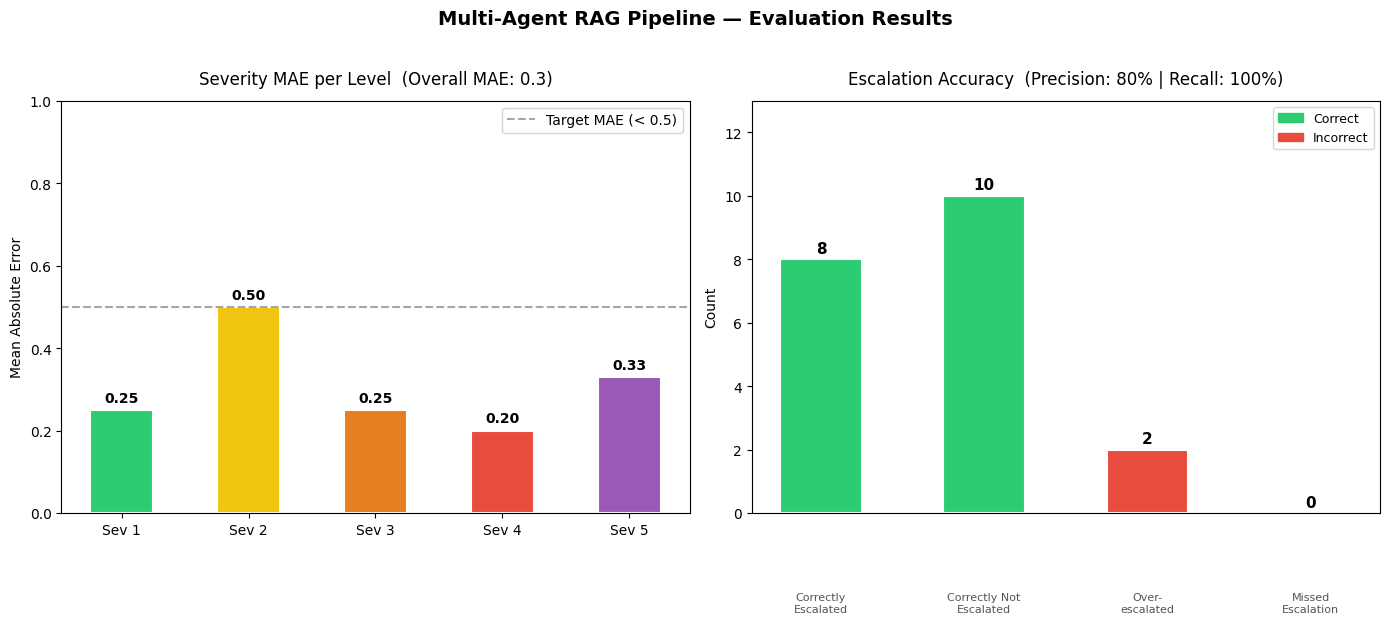

✅ Chart saved
   Overall Severity MAE : 0.3 (target: < 0.5)
   Escalation Precision : 80%
   Escalation Recall    : 100%


In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Multi-Agent RAG Pipeline — Evaluation Results',
             fontsize=14, fontweight='bold', y=1.02)

# ── Compute MAE per severity level from df_eval ───────────────
severity_levels = [1, 2, 3, 4, 5]
mae_per_level   = []

for level in severity_levels:
    level_rows = df_eval[df_eval["tagged_severity"] == level]
    if len(level_rows) > 0:
        mae = (level_rows["tagged_severity"] - level_rows["agent_severity"]).abs().mean()
    else:
        mae = 0.0
    mae_per_level.append(round(mae, 2))

# ── Overall MAE ───────────────────────────────────────────────
overall_mae = (df_eval["tagged_severity"] - df_eval["agent_severity"]).abs().mean()
overall_mae = round(overall_mae, 2)

# ── Chart 1: MAE per Severity Level ──────────────────────────
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#9b59b6']
severity_labels = ['Sev 1', 'Sev 2', 'Sev 3', 'Sev 4', 'Sev 5']

bars1 = axes[0].bar(severity_labels, mae_per_level,
                    color=colors, edgecolor='white', linewidth=1.5, width=0.5)

axes[0].set_title(f'Severity MAE per Level  (Overall MAE: {overall_mae})', pad=12)
axes[0].set_ylabel('Mean Absolute Error')
axes[0].set_ylim(0, max(mae_per_level) + 0.5 if max(mae_per_level) > 0 else 1.0)

# Target line
axes[0].axhline(y=0.5, color='gray', linestyle='--',
                alpha=0.7, label='Target MAE (< 0.5)')
axes[0].legend(loc='upper right')
axes[0].tick_params(axis='x', labelsize=10)

# Value labels on bars
for bar, val in zip(bars1, mae_per_level):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.2f}',
                 ha='center', fontweight='bold', fontsize=10)

# ── Compute escalation metrics from df_eval ───────────────────
tp = len(df_eval[(df_eval["tagged_escalate"] == True)  & (df_eval["agent_escalate"] == True)])
tn = len(df_eval[(df_eval["tagged_escalate"] == False) & (df_eval["agent_escalate"] == False)])
fp = len(df_eval[(df_eval["tagged_escalate"] == False) & (df_eval["agent_escalate"] == True)])
fn = len(df_eval[(df_eval["tagged_escalate"] == True)  & (df_eval["agent_escalate"] == False)])

precision = round(tp / (tp + fp), 2) if (tp + fp) > 0 else 0
recall    = round(tp / (tp + fn), 2) if (tp + fn) > 0 else 0

# ── Chart 2: Escalation Decision Accuracy ────────────────────
values    = [tp, tn, fp, fn]
colors2   = ['#2ecc71', '#2ecc71', '#e74c3c', '#e74c3c']
subtitles = ['Correctly\nEscalated', 'Correctly Not\nEscalated',
             'Over-\nescalated', 'Missed\nEscalation']
categories = ['True\nPositive', 'True\nNegative',
              'False\nPositive', 'False\nNegative']

bars2 = axes[1].bar(categories, values,
                    color=colors2, edgecolor='white', linewidth=1.5, width=0.5)

axes[1].set_title(f'Escalation Accuracy  (Precision: {precision:.0%} | Recall: {recall:.0%})', pad=12)
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, max(values) + 3)

# Value labels on bars
for bar, val in zip(bars2, values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 str(val),
                 ha='center', fontweight='bold', fontsize=11)

# Subtitle labels below x-axis
for bar, sub in zip(bars2, subtitles):
    axes[1].text(bar.get_x() + bar.get_width()/2, -2.5,
                 sub,
                 ha='center', va='top',
                 fontsize=8, color='#555555')

axes[1].set_xticklabels([])
axes[1].tick_params(axis='x', length=0)

# Legend
green_patch = mpatches.Patch(color='#2ecc71', label='Correct')
red_patch   = mpatches.Patch(color='#e74c3c', label='Incorrect')
axes[1].legend(handles=[green_patch, red_patch],
               loc='upper right', fontsize=9)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig('evaluation_results.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Chart saved")
print(f"   Overall Severity MAE : {overall_mae} (target: < 0.5)")
print(f"   Escalation Precision : {precision:.0%}")
print(f"   Escalation Recall    : {recall:.0%}")

##Past case demo

In [36]:
# Run 1 — logs the case
ticket_demo_1 = run_pipeline(
    "I was charged twice for my order, this is unacceptable!"
)


🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 
  PIPELINE START
  Query: I was charged twice for my order, this is unacceptable!
🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 

📊 AGENT 1: RETRIEVAL AGENT

📊 AGENT 2: EVALUATION AGENT

  Retrieved 3 support docs
  Retrieved 2 past cases

   🔴 Severity     : 4/5 — SERIOUS
   😤 Sentiment    : angry
   📁 Issue Type   : billing
   🔁 Repeat Issue : False
   🚨 Escalate     : True
   💬 Tone         : empathetic
   🧠 Reasoning    : Double charge, financial impact, customer is angry and finds it unacceptable.

💬 AGENT 3: RESPONSE AGENT

   Tone applied : empathetic (severity 4/5, sentiment: angry)

   📨 Response to customer:

   I understand how frustrating it must be to be charged twice for your order, and I sincerely apologize for this inconvenience. To resolve

🧑‍💼 AGENT 4: SUPERVISOR AGENT

   ─── SUPERVISOR DECISION ────────────────────────────
     🔬  Action          : escalate_rca                  
     💰  Compensation    : full_refund               

In [37]:
ticket_demo_2 = run_pipeline(
    "There are two identical charges on my account and I need this fixed"
)


🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 
  PIPELINE START
  Query: There are two identical charges on my account and I need this fixed
🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 

📊 AGENT 1: RETRIEVAL AGENT

📊 AGENT 2: EVALUATION AGENT

  Retrieved 3 support docs
  Retrieved 0 past cases

   🔴 Severity     : 4/5 — SERIOUS
   😤 Sentiment    : frustrated
   📁 Issue Type   : billing
   🔁 Repeat Issue : False
   🚨 Escalate     : True
   💬 Tone         : empathetic
   🧠 Reasoning    : Double charge on account, direct financial impact, needs fixing.

💬 AGENT 3: RESPONSE AGENT

   Tone applied : empathetic (severity 4/5, sentiment: frustrated)

   📨 Response to customer:

   I completely understand how frustrating it is to see duplicate charges on your account, and I apologize for

🧑‍💼 AGENT 4: SUPERVISOR AGENT

   ─── SUPERVISOR DECISION ────────────────────────────
     💰  Action          : compensate                    
     💰  Compensation    : full_refund                   
     🙋  Assigne

In [38]:

query_vector = embed_query(
    "There are two identical charges on my account and I need this fixed"
)

raw_results = index.query(
    vector=query_vector,
    top_k=10,
    include_metadata=True,
    namespace=NAMESPACE_LOGS
)

print(f"Raw results in action-logs (no threshold):\n")
for match in raw_results["matches"]:
    print(f"  score={match['score']:.4f} | "
          f"query={match['metadata'].get('query', '')[:60]}...")

Raw results in action-logs (no threshold):

  score=1.0005 | query=There are two identical charges on my account and I need thi...
  score=1.0005 | query=There are two identical charges on my account and I need thi...
  score=1.0005 | query=There are two identical charges on my account and I need thi...
  score=0.8158 | query=I was charged twice...
  score=0.8151 | query=I was charged twice for my order, this is unacceptable!...
  score=0.8151 | query=I was charged twice for my order, this is unacceptable!...
  score=0.5727 | query=This is completely unacceptable. I have contacted your suppo...
  score=0.5727 | query=This is completely unacceptable. I have contacted your suppo...
  score=0.5727 | query=This is completely unacceptable. I have contacted your suppo...
  score=0.5632 | query=I have been waiting for my order for 2 weeks now. The estima...


# Limitations & Assumptions

**Assumptions:**
- Severity scoring relies entirely on LLM judgement — no ground truth labels
- Action-logs threshold (0.88) is manually tuned, not optimised

**Current Limitations:**
- Single-turn only — no multi-turn conversation support
- Escalation actions are recommendations only — not connected to real systems
- No PII redaction — not suitable for real customer data without this
- Gemini API latency (~3-5s per agent) not suitable for real-time use without caching

**If Moving to Production:**
- Replace Bitext with real CRM data
- Add FastAPI service layer for concurrent requests
- Integrate with Zendesk/Freshdesk for real action execution
- Add PII redaction before embedding

##Latency check

In [39]:
import time

# Run a query to test run time
t_start = time.time()
ticket = run_pipeline("I was charged twice")
t_total = time.time() - t_start

print(f"Total latency: {t_total:.1f}s")
print(f"Gemini API calls: 5 (one per agent)")


🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 
  PIPELINE START
  Query: I was charged twice
🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 

📊 AGENT 1: RETRIEVAL AGENT

📊 AGENT 2: EVALUATION AGENT

  Retrieved 3 support docs
  Retrieved 1 past cases

   🔴 Severity     : 4/5 — SERIOUS
   😤 Sentiment    : frustrated
   📁 Issue Type   : billing
   🔁 Repeat Issue : False
   🚨 Escalate     : True
   💬 Tone         : empathetic
   🧠 Reasoning    : Financial impact from double charge requires immediate resolution.

💬 AGENT 3: RESPONSE AGENT

   Tone applied : empathetic (severity 4/5, sentiment: frustrated)

   📨 Response to customer:

   I understand how frustrating it must be to see a double charge on your account. Please don't worry, we're here to help you resolve this immediately. To investigate this for you, could you please provide your order number or any transaction details? We'll look into it right away to ensure everything is corrected.

🧑‍💼 AGENT 4: SUPERVISOR AGENT

   ─── SUPERVISOR DECISIO